### ARBOUET - CEMES-CNRS - 2026
### test program for opimization using pytorch
### context : amplitude and phase shaping for electron beam shaping - active compensation of TEM aberrations

Tensor shape: torch.Size([1080, 1920])
dtype: torch.float32
Tensor shape: torch.Size([1080, 1920])
dtype: torch.float32


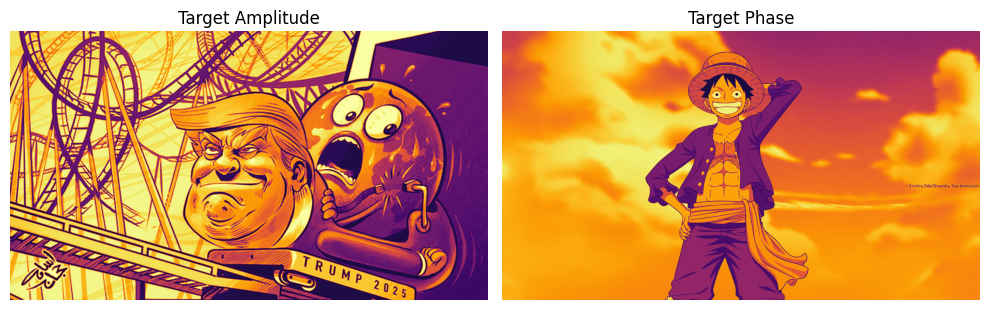

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from PIL import Image
import torch
from torchvision import transforms

def image_to_tensor(filename, nx, ny):
    img = Image.open(filename).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((ny, nx)), 
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(), ])
    img_tensor = transform(img).squeeze(0)
    print("Tensor shape:", img_tensor.shape)
    print("dtype:", img_tensor.dtype)
    return img_tensor

def gaussian_spot(shape, center, sigma):
    """
    Create a Gaussian spot centered at `center` with standard deviation `sigma` in a tensor of given `shape`.
    
    Args:
    - shape (tuple): The shape of the output tensor (Npix, Npix).
    - center (tuple): The coordinates of the center of the Gaussian spot (i0, j0).
    - sigma (float): The standard deviation of the Gaussian spot.
    
    Returns:
    - torch.Tensor: A tensor with a Gaussian spot.
    """
    Npix_x, Npix_y = shape
    i0, j0 = center
    x = torch.arange(Npix_x).float()
    y = torch.arange(Npix_y).float()
    X, Y = torch.meshgrid(x, y, indexing='ij')
    gauss = torch.exp(-((X - i0) ** 2 + (Y - j0) ** 2) / (2 * sigma ** 2))
    return gauss

def display_2_images(image_1, image_2, title_1, title_2  ):
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    axs[0].imshow(image_1, cmap = 'inferno')
    axs[0].set_title(title_1)
    axs[0].axis("off")
    axs[1].imshow(image_2, cmap = 'inferno')
    axs[1].set_title(title_2)
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()

def square_mask(shape, X0, Y0, S, dtype=torch.float32):
    """
    shape: (H, W)
    X0, Y0: center (column, row)
    S: lateral size of the square (pixels)
    """
    H, W = shape
    half = S // 2
    y = torch.arange(H).view(-1, 1)
    x = torch.arange(W).view(1, -1)
    mask = ((torch.abs(x - X0) <= half) & (torch.abs(y - Y0) <= half) )
    return mask.to(dtype)


N_slm_x = 1920
N_slm_y = 1080

directory = './'
file_amplitude = 'osama.png'
file_phase = 'one_piece.png'
image_amplitude = image_to_tensor(directory+file_amplitude, N_slm_x, N_slm_y)
image_phase = image_to_tensor(directory+file_phase, N_slm_x, N_slm_y)

display_2_images(image_amplitude, image_phase, "Target Amplitude", "Target Phase") 


Starting Optimization loop

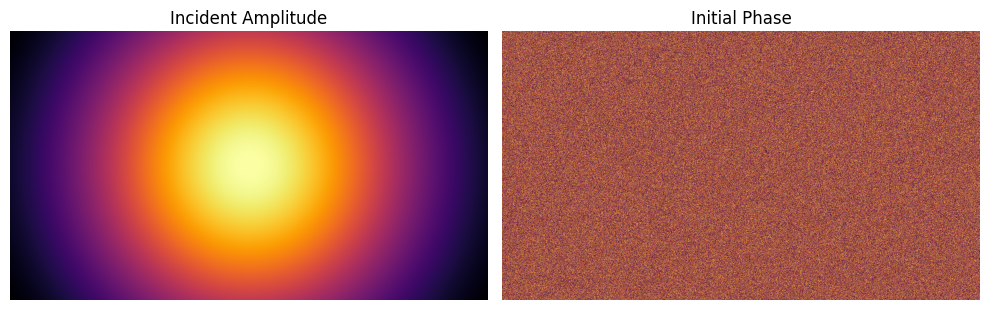

Iteration    0 | Loss = 1.7710e+19
Iteration   50 | Loss = 1.6730e+19
Iteration  100 | Loss = 1.5749e+19
Iteration  150 | Loss = 1.4764e+19
Iteration  200 | Loss = 1.3780e+19
Iteration  250 | Loss = 1.2802e+19
Iteration  300 | Loss = 1.1837e+19
Iteration  350 | Loss = 1.0893e+19
Iteration  400 | Loss = 9.9777e+18
Iteration  450 | Loss = 9.0983e+18
Iteration  500 | Loss = 8.2613e+18
Iteration  550 | Loss = 7.4721e+18
Iteration  600 | Loss = 6.7345e+18


In [ ]:
phase_ini  = torch.rand(N_slm_y, N_slm_x)*2*torch.pi
amplitude_inc = gaussian_spot((N_slm_y,N_slm_x),(N_slm_y // 2, N_slm_x // 2), 500)

display_2_images(amplitude_inc, phase_ini, "Incident Amplitude", "Initial Phase") 


image_amplitude = image_amplitude / image_amplitude.max()
target_amplitude      = image_amplitude.clone().detach().requires_grad_(True)

phase = phase_ini.clone().detach().requires_grad_(True)
cplx_target = image_amplitude * torch.exp(1j * image_phase)
target_cplx_amplitude = cplx_target.clone().detach().requires_grad_(True)

optimizer = optim.Adam([phase], lr=0.001) # optimizer
n_iter = 5001                             # Number of optimization loops

shape = (N_slm_x, N_slm_y)
X0 = int(0.5 * N_slm_x )
Y0 = int(0.5 * N_slm_y )
size = 900
mask = square_mask((N_slm_y, N_slm_x), X0=X0, Y0=Y0, S=size)

for it in range(n_iter):
    optimizer.zero_grad()
    field = torch.exp(1j * phase) * amplitude_inc
    focal_field = torch.fft.fftshift(torch.fft.fft2(field))

    intensity    = torch.abs(focal_field) ** 2
    phase_output = torch.angle(focal_field)
    # intensity = intensity / intensity.detach().max()
    # Loss function for amplitude and phase
    loss = 10**9 * torch.sum(torch.abs(focal_field * mask - target_cplx_amplitude * mask)**1.5 )
   # Loss function for intensity only - lr = 0.001 - 5000 iterations OK
   # loss = torch.mean((torch.sqrt(intensity + 1e-8) -
   #                torch.sqrt(target_intensity + 1e-8)) ** 2)
    loss.backward()
    optimizer.step()

    if it % 50 == 0:
        print(f"Iteration {it:4d} | Loss = {loss.item():.4e}")

output_amplitude = torch.abs(focal_field)
output_phase = torch.angle(focal_field)

display_2_images((output_amplitude * mask).detach().numpy() , target_amplitude.detach().numpy(), "Optimized Amplitude", "Target Amplitude") 
display_2_images(output_phase.detach().numpy(),image_phase.detach().numpy(), "Optimized Phase", "Target Phase") 

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
im =plt.imshow(output_phase.detach().numpy(), vmin = -np.pi, vmax = np.pi, cmap = 'magma') 
plt.colorbar(im, ax = ax)


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(image_phase.detach().numpy(), vmin = -np.pi, vmax = np.pi, cmap = 'magma') 
plt.colorbar(im, ax = ax)